In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

In [43]:
gg = pd.read_csv("../data/dummy_google_ads_data.csv")
ga4 = pd.read_csv("../data/dummy_ga4_data.csv")

In [44]:
ga4.columns = ["data", "origem", "campanha", "sessoes", "receita"]

gg.columns = ["data", "campanha", "custo"]

In [45]:
ga4["data"] = pd.to_datetime(ga4["data"].astype("str"), format="%Y%m%d")

In [46]:
gg["data"] = pd.to_datetime(gg["data"])

In [47]:
#group

ads_agrupado = gg.groupby(["data", "campanha"])["custo"].sum().reset_index()
ga4_agrupado = ga4.groupby(["data", "campanha"])["receita"].sum().reset_index()

In [48]:
df_final = pd.merge(ads_agrupado, ga4_agrupado, on=["data", "campanha"], how="left")

df_final["receita"] = df_final["receita"].fillna(0)

In [49]:
df_diario = df_final.groupby("data")[["custo", "receita"]].sum().reset_index()

df_diario = df_diario[df_diario["custo"] > 100]

In [50]:
filtro_performance = ~df_final["campanha"].str.contains("branding", case=False)
df_performance = df_final[filtro_performance].groupby("data")[["custo", "receita"]].sum().reset_index()

In [51]:
#coeficientes
coeficiente_sInst = np.polyfit(df_performance["custo"], df_performance["receita"], 2)
a, b, c = coeficiente_sInst

TARGET_ROAS = 5.5

In [52]:
raizes_roas = np.roots([a, b - TARGET_ROAS, c])

In [53]:
investimento_target = None
for r in raizes_roas:
    if np.isreal(r) and r > 0:
        investimento_target = np.real(r)
        break

if investimento_target:
    receita_target = np.polyval(coeficiente_sInst, investimento_target)
else:
    print("Atenção: O modelo matemático diz que esse ROAS nunca é atingido na curva ajustada.")
    investimento_target = 0
    receita_target = 0
    
ponto_saturacao_x = -b / (2 * a)
receita_maxima_y = np.polyval(coeficiente_sInst, ponto_saturacao_x)

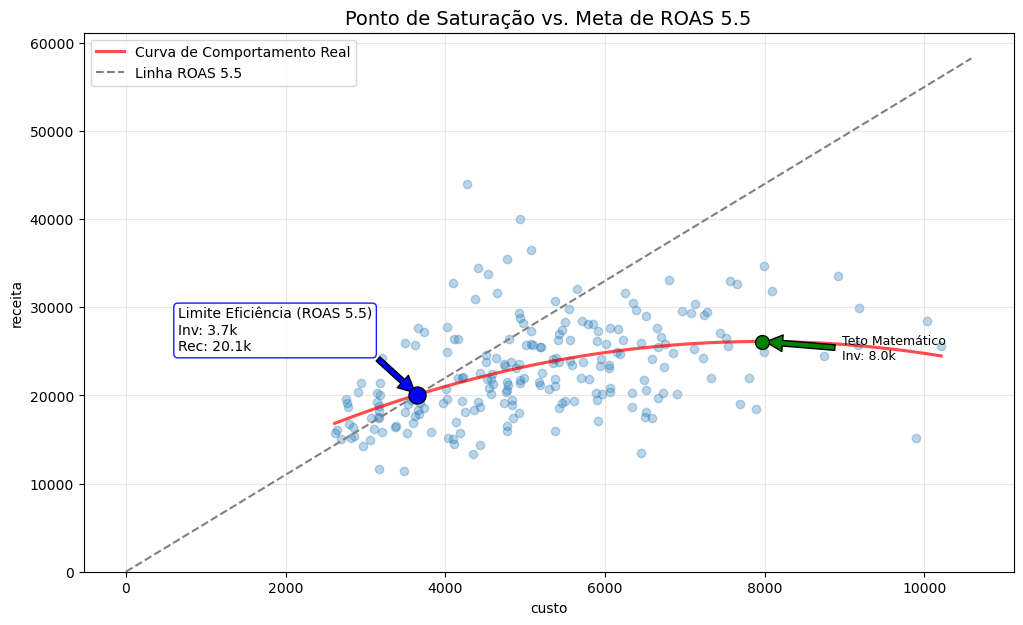

In [54]:
plt.figure(figsize=(12, 7))

sns.regplot(
    data=df_performance, x='custo', y='receita', order=2, ci=None,
    line_kws={'color': 'red', 'alpha': 0.7, 'label': 'Curva de Comportamento Real'},
    scatter_kws={'alpha': 0.3}
)

xlims = plt.gca().get_xlim()
x_vals = np.linspace(0, xlims[1], 100)
y_vals = TARGET_ROAS * x_vals
plt.plot(x_vals, y_vals, color='gray', linestyle='--', label=f'Linha ROAS {TARGET_ROAS}')

if investimento_target > 0:
    plt.scatter(investimento_target, receita_target, color='blue', s=150, zorder=5, edgecolors='black')
    plt.annotate(
        f'Limite Eficiência (ROAS {TARGET_ROAS})\nInv: {investimento_target/1000:.1f}k\nRec: {receita_target/1000:.1f}k',
        xy=(investimento_target, receita_target),
        xytext=(investimento_target - 3000, receita_target + 5000),
        arrowprops=dict(facecolor='blue', shrink=0.05),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="blue", alpha=0.9)
    )

plt.scatter(ponto_saturacao_x, receita_maxima_y, color='green', s=100, zorder=5, edgecolors='black')
plt.annotate(
    f'Teto Matemático\nInv: {ponto_saturacao_x/1000:.1f}k',
    xy=(ponto_saturacao_x, receita_maxima_y),
    xytext=(ponto_saturacao_x + 1000, receita_maxima_y - 2000),
    arrowprops=dict(facecolor='green', shrink=0.05),
    fontsize=9
)

plt.title(f'Ponto de Saturação vs. Meta de ROAS {TARGET_ROAS}', fontsize=14)
plt.ylim(bottom=0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [55]:
# roas marginal
x_custo = np.linspace(df_performance['custo'].min(), df_performance['custo'].max(), 100)
roas_marginal = (2 * a * x_custo) + b


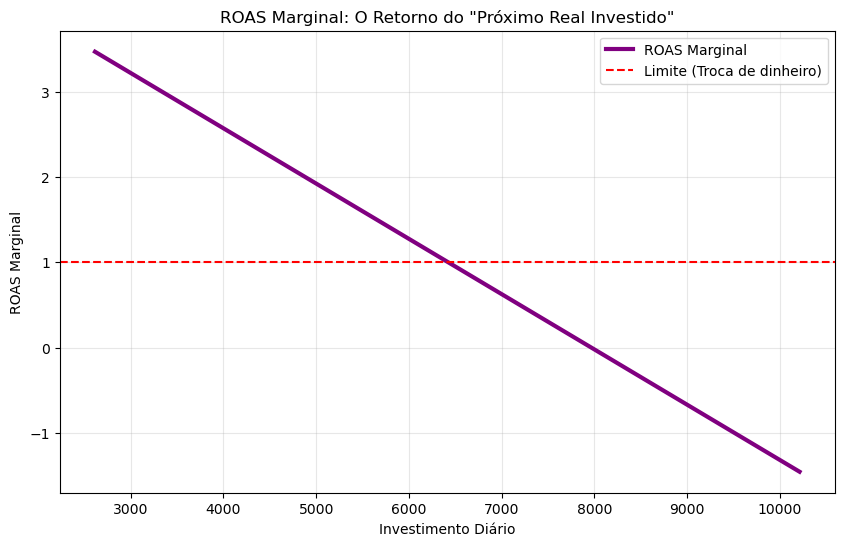

In [56]:
plt.figure(figsize=(10, 6))

plt.plot(x_custo, roas_marginal, color='purple', linewidth=3, label='ROAS Marginal')

plt.axhline(1, color='red', linestyle='--', label='Limite (Troca de dinheiro)')

plt.title('ROAS Marginal: O Retorno do "Próximo Real Investido"')
plt.xlabel('Investimento Diário')
plt.ylabel('ROAS Marginal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [57]:
filtro_ads = ga4["origem"] == "google / cpc"
filtro_organic = ga4["origem"].str.contains("organic|(direct) / (none)")

ads_sessoes = ga4[filtro_ads].groupby("data")["sessoes"].sum().reset_index()
organic_sessoes = ga4[filtro_organic].groupby("data")["sessoes"].sum().reset_index()

/tmp/ipykernel_35452/1544356010.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  filtro_organic = ga4["origem"].str.contains("organic|(direct) / (none)")


In [58]:
df_canibalizacao = pd.merge(ads_sessoes, organic_sessoes, how="inner", on="data")

In [59]:
corr = df_canibalizacao["sessoes_x"].corr(df_canibalizacao["sessoes_y"])
print(f"Correlação de Sessões Pagas e Organicas: {corr:.2f}")

Correlação de Sessões Pagas e Organicas: -0.07


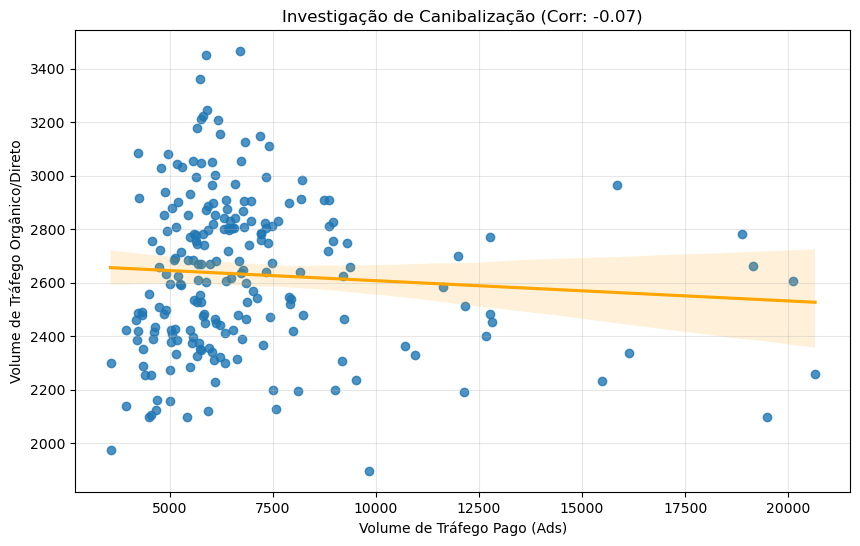

In [60]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_canibalizacao, 
    x='sessoes_x', 
    y='sessoes_y',
    line_kws={'color': 'orange'}
)
plt.title(f'Investigação de Canibalização (Corr: {corr:.2f})')
plt.xlabel('Volume de Tráfego Pago (Ads)')
plt.ylabel('Volume de Tráfego Orgânico/Direto')
plt.grid(True, alpha=0.3)
plt.show()

In [61]:
pmax_Inv = gg[gg["campanha"] == "Performance Max - Todos Produtos [Brasil]"].groupby("data")["custo"].sum().reset_index()
shpp_Inv = gg[gg["campanha"] == "Shopping Padrão - Top Produtos [Especifica]"].groupby("data")["custo"].sum().reset_index()
pmaxPromo_Inv = gg[gg["campanha"] == "Performance Max - Promoção"].groupby("data")["custo"].sum().reset_index()

pmax_Rev = ga4[ga4["campanha"] == "Performance Max - Todos Produtos [Brasil]"].groupby("data")["receita"].sum().reset_index()
shpp_Rev = ga4[ga4["campanha"] == "Shopping Padrão - Top Produtos [Especifica]"].groupby("data")["receita"].sum().reset_index()
pmaxPromo_Rev = ga4[ga4["campanha"] == "Performance Max - Promoção"].groupby("data")["receita"].sum().reset_index()

In [62]:
#merge
pmax = pd.merge(pmax_Inv, pmax_Rev, how="left", on="data")
shpp = pd.merge(shpp_Inv, shpp_Rev, how="left", on="data")
pmaxPromo = pd.merge(pmaxPromo_Inv, pmaxPromo_Rev, how="left", on="data")

In [63]:
# campanhas
df_campanhas = df_final.groupby('campanha').agg({
    'custo': 'sum',
    'receita': 'sum'
}).reset_index()

df_campanhas['ROAS'] = df_campanhas['receita'] / df_campanhas['custo']

df_campanhas = df_campanhas[df_campanhas['custo'] > 500]

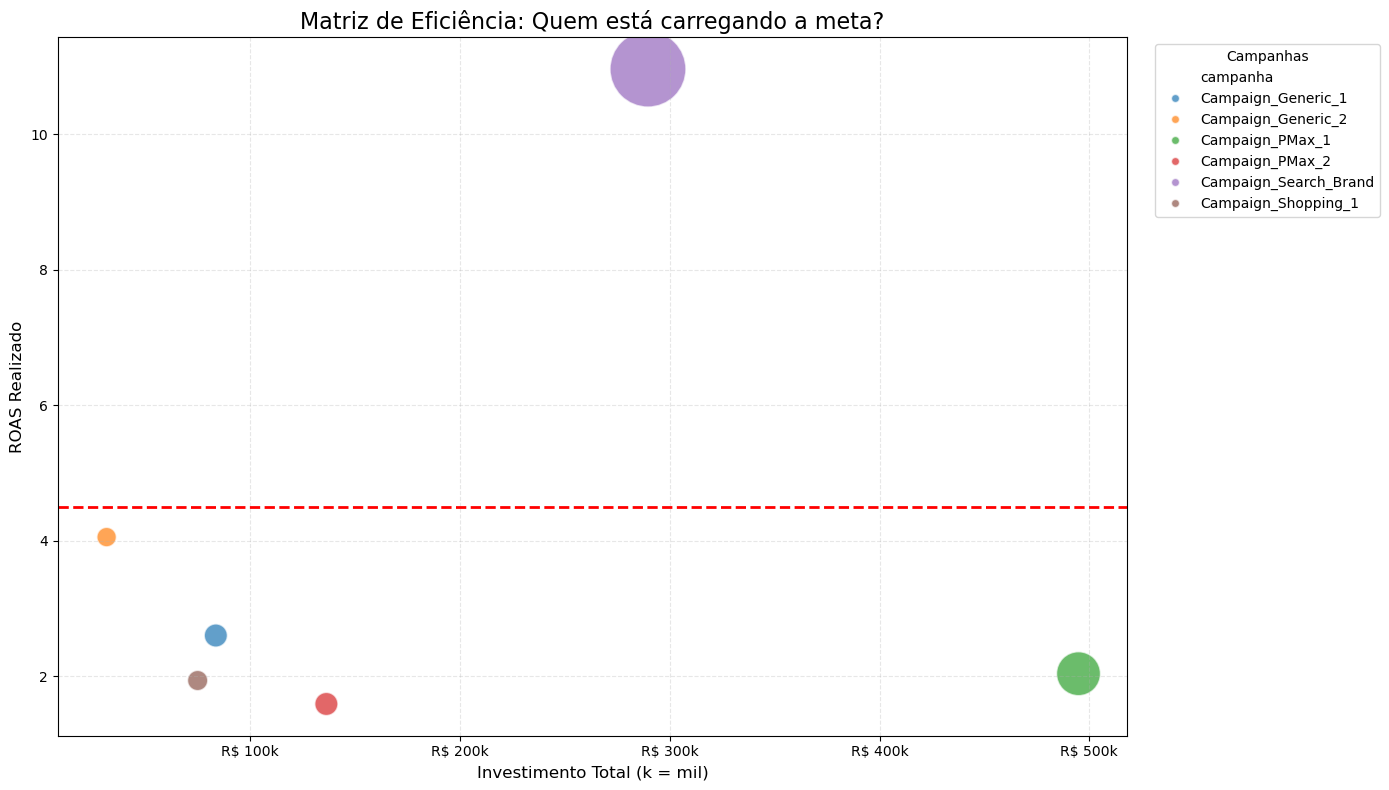

In [64]:
plt.figure(figsize=(14, 8))

scatter = sns.scatterplot(
    data=df_campanhas,
    x='custo',
    y='ROAS',
    size='receita',
    sizes=(200, 3000),
    hue='campanha',
    alpha=0.7,
    legend='brief'
)

h, l = scatter.get_legend_handles_labels()

n_campanhas = df_campanhas['campanha'].nunique()

plt.legend(h[0:n_campanhas+1], l[0:n_campanhas+1], bbox_to_anchor=(1.02, 1), loc='upper left', title='Campanhas')

plt.axhline(4.5, color='red', linestyle='--', linewidth=2, label='Meta ROAS 4.5')

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'R$ {x/1000:.0f}k'))

plt.title('Matriz de Eficiência: Quem está carregando a meta?', fontsize=16)
plt.xlabel('Investimento Total (k = mil)', fontsize=12)
plt.ylabel('ROAS Realizado', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [65]:
def analisar_saturacao_tipo(df, termo_busca, cor_plot, ax):
    mask = df['campanha'].str.contains(termo_busca, case=False)
    df_tipo = df[mask].groupby('data')[['custo', 'receita']].sum().reset_index()
    
    if len(df_tipo) < 10:
        ax.text(0.5, 0.5, f'Dados insuficientes para {termo_busca}', ha='center')
        return

    coefs = np.polyfit(df_tipo['custo'], df_tipo['receita'], 2)
    a, b, c = coefs
    
    invest_max_lucro = (1 - b) / (2 * a)
    
    invest_meta_roas = (4.5 - b) / (2 * a)

    sns.regplot(data=df_tipo, x='custo', y='receita', order=2, ax=ax, 
                color=cor_plot, scatter_kws={'alpha': 0.3}, line_kws={'label': f'Curva {termo_busca.upper()}'})
    
    xlims = ax.get_xlim()
    ax.plot(xlims, [4.5*x for x in xlims], color='gray', linestyle='--', alpha=0.5, label='Meta ROAS 4.5')

    if invest_meta_roas > 0:
        rec_meta = np.polyval(coefs, invest_meta_roas)
        ax.scatter(invest_meta_roas, rec_meta, color='black', s=100, zorder=5)
        ax.annotate(f'Teto {termo_busca.upper()} (ROAS 4.5):\nR$ {invest_meta_roas:.0f}', 
                    (invest_meta_roas, rec_meta), xytext=(invest_meta_roas, rec_meta + (rec_meta*0.2)),
                    arrowprops=dict(facecolor='black', shrink=0.05))

    ax.set_title(f'Saturação: {termo_busca.upper()}')
    ax.legend()
    ax.grid(True, alpha=0.3)



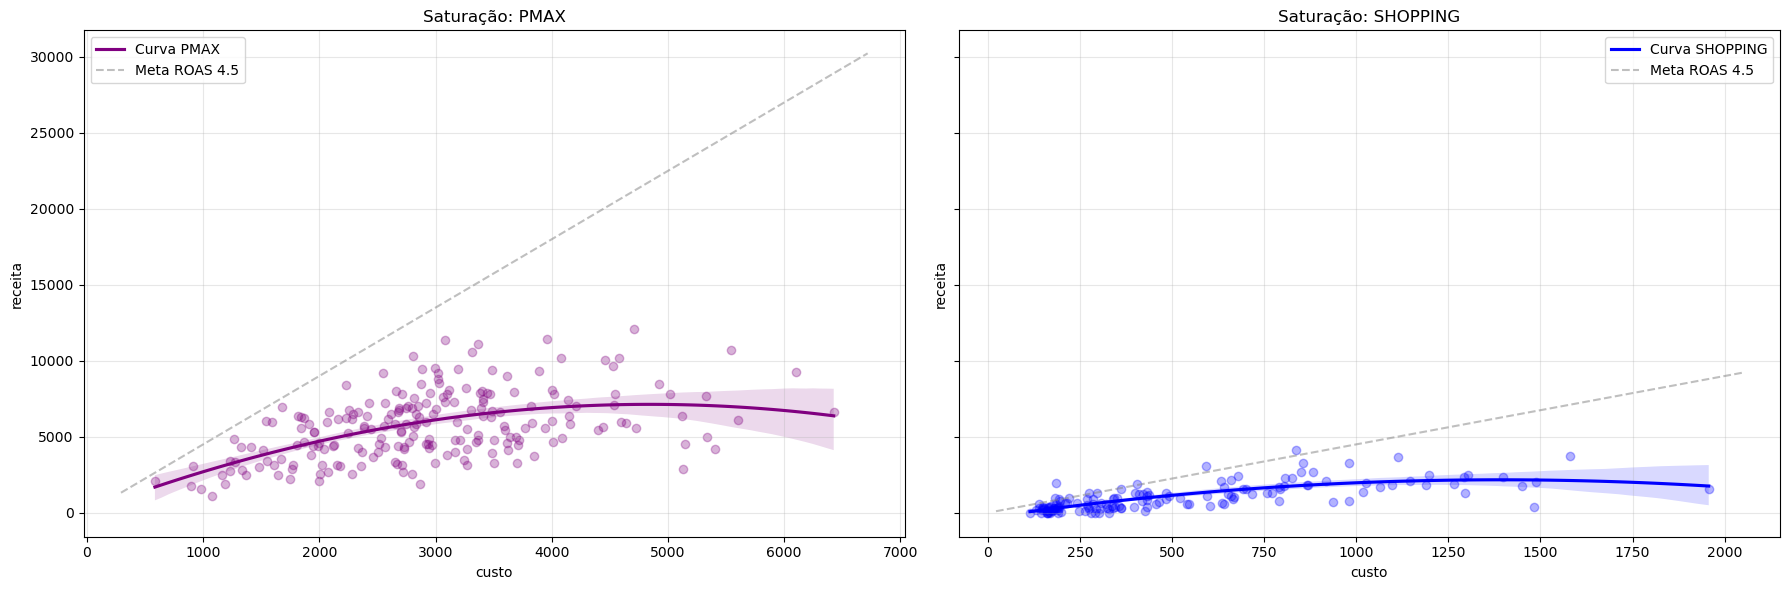

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

analisar_saturacao_tipo(df_final, 'pmax', 'purple', axes[0])

analisar_saturacao_tipo(df_final, 'shopping', 'blue', axes[1])

plt.tight_layout()
plt.show()